#Instalando dependencias e configurando o ambiente

##TODO

- Etapas de análise comparativa por parágrafos e k-caracteres.

- Executar Grafo por Parágrafos: Rodar a lógica de construção do grafo G_paragrafo para processar os textos e extrair as métricas de co-ocorrência em nível de parágrafo.

- Extração de NER e Grafo de Co-ocorrência (Nível de K-Caracteres): Implementar a lógica para dividir os textos em janelas de 'k' caracteres, identificar as entidades e construir o terceiro grafo de comparação.

- Análise Comparativa Final: Criar uma visualização e uma tabela comparativa entre os três métodos (Sentença, Parágrafo, K-Caracteres) discutindo densidade, número de conexões e fidelidade dos relacionamentos encontrados.

- Consolidar todas as descobertas em um relatório final dentro do próprio notebook, destacando qual granularidade se mostrou mais eficaz para o contexto do Spygate.
---
maybe??<br>
1- contar quantidade de caminhos de N passos entre dois nós<br>
2- detecção de clusters<br>
3- calculo do menor caminho medio<br>

In [ ]:
!pip install -U openai-whisper yt-dlp spacy


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#baixando os videos do youtube

In [ ]:
import yt_dlp

videos = [
    'https://www.youtube.com/watch?v=jt7Sq8uaZEI',
    'https://www.youtube.com/watch?v=L4xZ__SBu94',
    'https://www.youtube.com/watch?v=Xqooy0UuSoA',
    'https://www.youtube.com/watch?v=o9FCP3DzDVk',
    'https://www.youtube.com/watch?v=E7EFqgKGRLc',
    'https://www.youtube.com/watch?v=Xqooy0UuSoA',
    'https://www.youtube.com/watch?v=mFldhKWtTak',
    'https://www.youtube.com/watch?v=x1WIVLqVVlA'
]


opcoes = {
    'paths': {'home': '/content/drive/MyDrive/ED2/Proj-1/audios'},
    'format': 'bestaudio/best', # Escolhe a melhor qualidade de áudio
    'postprocessors': [{
        'key': 'FFmpegExtractAudio',
        'preferredcodec': 'mp3',    # Converte para mp3
        'preferredquality': '192',  # Qualidade do áudio
    }],

}

print("Baixando o áudio...")

# Executa o download com as opções configuradas
with yt_dlp.YoutubeDL(opcoes) as ydl:
    ydl.download([url for url in videos])

print("Download concluído! Arquivo 'meu_audio_baixado.mp3' pronto para o Whisper.")


Baixando o áudio...
[youtube] Extracting URL: https://www.youtube.com/watch?v=jt7Sq8uaZEI
[youtube] jt7Sq8uaZEI: Downloading webpage


[youtube] jt7Sq8uaZEI: Downloading android vr player API JSON
[info] jt7Sq8uaZEI: Downloading 1 format(s): 251
[download] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/ENTENDA O ESCÂNDALO DE ESPIONAGEM DA F1 EM 2007 [jt7Sq8uaZEI].webm
[download] 100% of    7.21MiB in 00:00:00 at 15.73MiB/s  
[ExtractAudio] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/ENTENDA O ESCÂNDALO DE ESPIONAGEM DA F1 EM 2007 [jt7Sq8uaZEI].mp3
Deleting original file /content/drive/MyDrive/ED2/Proj-1/audios/ENTENDA O ESCÂNDALO DE ESPIONAGEM DA F1 EM 2007 [jt7Sq8uaZEI].webm (pass -k to keep)
[youtube] Extracting URL: https://www.youtube.com/watch?v=L4xZ__SBu94
[youtube] L4xZ__SBu94: Downloading webpage


[youtube] L4xZ__SBu94: Downloading android vr player API JSON
[info] L4xZ__SBu94: Downloading 1 format(s): 251
[download] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/O QUE FOI O ESCÂNDALO DE ESPIONAGEM DA MCLAREN EM 2007 (SPYGATE) - Primeira Fila [L4xZ__SBu94].webm
[download] 100% of   10.75MiB in 00:00:01 at 6.81MiB/s   
[ExtractAudio] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/O QUE FOI O ESCÂNDALO DE ESPIONAGEM DA MCLAREN EM 2007 (SPYGATE) - Primeira Fila [L4xZ__SBu94].mp3
Deleting original file /content/drive/MyDrive/ED2/Proj-1/audios/O QUE FOI O ESCÂNDALO DE ESPIONAGEM DA MCLAREN EM 2007 (SPYGATE) - Primeira Fila [L4xZ__SBu94].webm (pass -k to keep)
[youtube] Extracting URL: https://www.youtube.com/watch?v=Xqooy0UuSoA
[youtube] Xqooy0UuSoA: Downloading webpage


[youtube] Xqooy0UuSoA: Downloading android vr player API JSON
[info] Xqooy0UuSoA: Downloading 1 format(s): 251
[download] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/O Maior Escândalo de Roubo da História da F1 [Xqooy0UuSoA].webm
[download] 100% of   32.62MiB in 00:00:03 at 9.16MiB/s   
[ExtractAudio] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/O Maior Escândalo de Roubo da História da F1 [Xqooy0UuSoA].mp3
Deleting original file /content/drive/MyDrive/ED2/Proj-1/audios/O Maior Escândalo de Roubo da História da F1 [Xqooy0UuSoA].webm (pass -k to keep)
[youtube] Extracting URL: https://www.youtube.com/watch?v=o9FCP3DzDVk
[youtube] o9FCP3DzDVk: Downloading webpage


[youtube] o9FCP3DzDVk: Downloading android vr player API JSON
[info] o9FCP3DzDVk: Downloading 1 format(s): 251
[download] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/The Biggest Cheating Scandal in Formula 1 History [o9FCP3DzDVk].webm
[download] 100% of   19.38MiB in 00:00:00 at 43.48MiB/s  
[ExtractAudio] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/The Biggest Cheating Scandal in Formula 1 History [o9FCP3DzDVk].mp3
Deleting original file /content/drive/MyDrive/ED2/Proj-1/audios/The Biggest Cheating Scandal in Formula 1 History [o9FCP3DzDVk].webm (pass -k to keep)
[youtube] Extracting URL: https://www.youtube.com/watch?v=E7EFqgKGRLc
[youtube] E7EFqgKGRLc: Downloading webpage


[youtube] E7EFqgKGRLc: Downloading android vr player API JSON
[info] E7EFqgKGRLc: Downloading 1 format(s): 251
[download] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/The $100,000,000 Formula 1 Spy Story： Inside The Most Expensive Sports Scandal In History： EXPLAINED [E7EFqgKGRLc].webm
[download] 100% of   19.96MiB in 00:00:00 at 22.03MiB/s  
[ExtractAudio] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/The $100,000,000 Formula 1 Spy Story： Inside The Most Expensive Sports Scandal In History： EXPLAINED [E7EFqgKGRLc].mp3
Deleting original file /content/drive/MyDrive/ED2/Proj-1/audios/The $100,000,000 Formula 1 Spy Story： Inside The Most Expensive Sports Scandal In History： EXPLAINED [E7EFqgKGRLc].webm (pass -k to keep)
[youtube] Extracting URL: https://www.youtube.com/watch?v=Xqooy0UuSoA
[youtube] Xqooy0UuSoA: Downloading webpage


[youtube] Xqooy0UuSoA: Downloading android vr player API JSON
[info] Xqooy0UuSoA: Downloading 1 format(s): 251
[download] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/O Maior Escândalo de Roubo da História da F1 [Xqooy0UuSoA].webm
[download] 100% of   32.62MiB in 00:00:00 at 42.70MiB/s  
[ExtractAudio] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/O Maior Escândalo de Roubo da História da F1 [Xqooy0UuSoA].mp3
Deleting original file /content/drive/MyDrive/ED2/Proj-1/audios/O Maior Escândalo de Roubo da História da F1 [Xqooy0UuSoA].webm (pass -k to keep)
[youtube] Extracting URL: https://www.youtube.com/watch?v=mFldhKWtTak
[youtube] mFldhKWtTak: Downloading webpage


[youtube] mFldhKWtTak: Downloading android vr player API JSON
[info] mFldhKWtTak: Downloading 1 format(s): 251
[download] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/The Biggest Corruption Scandal in Formula 1 History [mFldhKWtTak].webm
[download] 100% of   22.84MiB in 00:00:00 at 48.32MiB/s  
[ExtractAudio] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/The Biggest Corruption Scandal in Formula 1 History [mFldhKWtTak].mp3
Deleting original file /content/drive/MyDrive/ED2/Proj-1/audios/The Biggest Corruption Scandal in Formula 1 History [mFldhKWtTak].webm (pass -k to keep)
[youtube] Extracting URL: https://www.youtube.com/watch?v=x1WIVLqVVlA
[youtube] x1WIVLqVVlA: Downloading webpage


[youtube] x1WIVLqVVlA: Downloading android vr player API JSON
[info] x1WIVLqVVlA: Downloading 1 format(s): 251
[download] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/Spy-gate Full Documentary [x1WIVLqVVlA].webm
[download] 100% of   22.75MiB in 00:00:01 at 14.49MiB/s  
[ExtractAudio] Destination: /content/drive/MyDrive/ED2/Proj-1/audios/Spy-gate Full Documentary [x1WIVLqVVlA].mp3
Deleting original file /content/drive/MyDrive/ED2/Proj-1/audios/Spy-gate Full Documentary [x1WIVLqVVlA].webm (pass -k to keep)
Download concluído! Arquivo 'meu_audio_baixado.mp3' pronto para o Whisper.


#Transcrição

In [ ]:
import whisper
import os

# Caminhos de entrada e saída
audio_dir = '/content/drive/MyDrive/ED2/Proj-1/audios/'
output_dir = '/content/drive/MyDrive/ED2/Proj-1/transcribed/'

# Cria o diretório de saída se não existir
os.makedirs(output_dir, exist_ok=True)

# 1. Carrega o modelo
print("Carregando o modelo large...")
modelo = whisper.load_model("large")

# Lista os arquivos de áudio
arquivos = [f for f in os.listdir(audio_dir) if f.endswith(('.mp3', '.webm', '.m4a', '.wav'))]

print(f"Encontrados {len(arquivos)} arquivos para transcrição.")

for nome_arquivo in arquivos:
    caminho_audio = os.path.join(audio_dir, nome_arquivo)
    print(f"Transcrevendo: {nome_arquivo}...")

    # 2. Faz a transcrição
    resultado = modelo.transcribe(caminho_audio, verbose=False)
    texto_transcrito = resultado["text"]

    # 3. Define o nome do arquivo de texto (mesmo nome do áudio, mas .txt)
    nome_txt = os.path.splitext(nome_arquivo)[0] + ".txt"
    caminho_txt = os.path.join(output_dir, nome_txt)

    # 4. Salva o resultado
    with open(caminho_txt, "w", encoding="utf-8") as arquivo_saida:
        arquivo_saida.write(texto_transcrito)

    print(f"Salvo em: {nome_txt}")

print("\nProcesso concluído! Todas as transcrições estão em:", output_dir)

Carregando o modelo large...


100%|██████████████████████████████████████| 2.88G/2.88G [00:16<00:00, 182MiB/s]


Encontrados 7 arquivos para transcrição.
Transcrevendo: ENTENDA O ESCÂNDALO DE ESPIONAGEM DA F1 EM 2007 [jt7Sq8uaZEI].mp3...
Detected language: Portuguese


100%|██████████| 48656/48656 [03:31<00:00, 229.93frames/s]


Salvo em: ENTENDA O ESCÂNDALO DE ESPIONAGEM DA F1 EM 2007 [jt7Sq8uaZEI].txt
Transcrevendo: O QUE FOI O ESCÂNDALO DE ESPIONAGEM DA MCLAREN EM 2007 (SPYGATE) - Primeira Fila [L4xZ__SBu94].mp3...
Detected language: Portuguese


...

Salvo em: The $100,000,000 Formula 1 Spy Story： Inside The Most Expensive Sports Scandal In History： EXPLAINED [E7EFqgKGRLc].txt
Transcrevendo: The Biggest Corruption Scandal in Formula 1 History [mFldhKWtTak].mp3...
Detected language: English


100%|██████████| 128260/128260 [08:05<00:00, 264.41frames/s]


Salvo em: The Biggest Corruption Scandal in Formula 1 History [mFldhKWtTak].txt
Transcrevendo: Spy-gate Full Documentary [x1WIVLqVVlA].mp3...
Detected language: English


100%|██████████| 170338/170338 [10:51<00:00, 261.36frames/s]

Salvo em: Spy-gate Full Documentary [x1WIVLqVVlA].txt

Processo concluído! Todas as transcrições estão em: /content/drive/MyDrive/ED2/Proj-1/transcribed/


# Processando os dados transcritos

In [8]:
!pip install spacy
!python -m spacy download en_core_web_md, en_core_web_sm
!python -m spacy download pt_core_news_md, pt_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 60.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 14.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [17]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re
nlp = spacy.load("pt_core_news_md")


whitelist = ["Nigel Stepney", "Mike Coughlan", "Fernando Alonso", "Ron Dennis",
             "Lewis Hamilton", "Ferrari", "McLaren", "FIA", "Honda", "Renault"]
mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney",
    "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan",
    "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso",
    "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa",
    "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton",
    "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari",
    "McLaren Mercedes": "McLaren",
    "FIA": "FIA",
    "WMSC": "FIA",
    "780-page dossier": "Dossiê",
    "Honda": "Honda",
    "Felipe Massa": "Felipe Massa",
    "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley",
    "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone",
    "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore",
    "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo",
    "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)",
    "Dossier": "Dossiê",
    "780 pages": "Dossiê"
})

whitelist_estrita = list(mapeamento_nomes.keys())
G = nx.Graph()
pasta_txt = "/content/drive/MyDrive/ED2/Proj-1/transcribed"
arquivos = [f for f in os.listdir(pasta_txt) if f.endswith('.txt')]

for nome_arquivo in arquivos:
    with open(os.path.join(pasta_txt, nome_arquivo), 'r') as f:
        texto = f.read()

    #sentenças
    doc = nlp(texto)
    for sent in doc.sents:
        # apenas os termos da Whitelist

        ents_na_frase = []
        texto_sentenca = sent.text.lower()

        for termo in whitelist_estrita:

            if re.search(rf'\b{re.escape(termo)}\b', sent.text, re.IGNORECASE):
                ents_na_frase.append(mapeamento_nomes[termo])

        ents_na_frase = list(set(ents_na_frase))

        for i in range(len(ents_na_frase)):
            for j in range(i + 1, len(ents_na_frase)):
                u, v = ents_na_frase[i], ents_na_frase[j]
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)

# Gerar e salvar o grafo

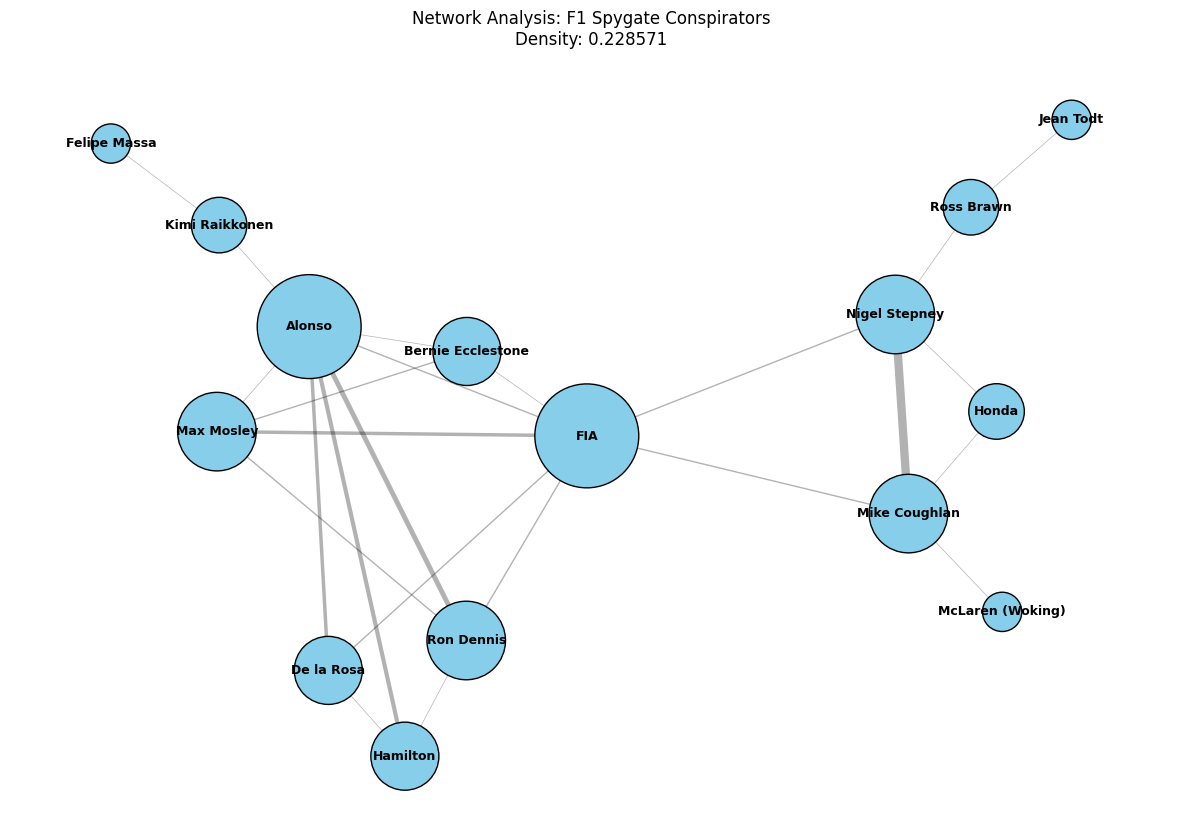

In [18]:
plt.figure(figsize=(15, 10))
# Usar o layout Kamada-Kawai ajuda a evitar a sobreposição de nomes
pos = nx.kamada_kawai_layout(G)


graus = dict(G.degree())

nx.draw_networkx_nodes(G, pos, node_size=[v * 800 for v in graus.values()], node_color='skyblue', edgecolors='black')
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='black', width=[G[u][v]['weight']*0.5 for u, v in G.edges()])
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

plt.title(f"Network Analysis: F1 Spygate Conspirators\nDensity: {nx.density(G):.6f}")
plt.axis('off')
plt.show()

nx.write_graphml(G, "/content/drive/MyDrive/ED2/Proj-1/spygate_graph_pt-ver.graphml")

#testando com o modelo em ingles

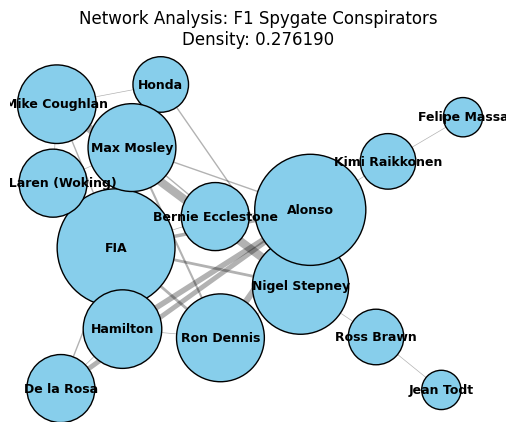

In [19]:
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os
import re
nlp = spacy.load("en_core_web_md")


whitelist = ["Nigel Stepney", "Mike Coughlan", "Fernando Alonso", "Ron Dennis",
             "Lewis Hamilton", "Ferrari", "McLaren", "FIA", "Honda", "Renault"]
mapeamento_nomes = {
    "Nigel Stepney": "Nigel Stepney",
    "Stepney": "Nigel Stepney",
    "Mike Coughlan": "Mike Coughlan",
    "Coughlan": "Mike Coughlan",
    "Fernando Alonso": "Alonso",
    "Alonso": "Alonso",
    "Pedro de la Rosa": "De la Rosa",
    "Ron Dennis": "Ron Dennis",
    "Lewis Hamilton": "Hamilton",
    "Jean Todt": "Jean Todt",
    "Scuderia Ferrari": "Ferrari",
    "McLaren Mercedes": "McLaren",
    "FIA": "FIA",
    "WMSC": "FIA",
    "780-page dossier": "Dossiê",
    "Honda": "Honda",
    "Felipe Massa": "Felipe Massa",
    "Kimi Raikkonen": "Kimi Raikkonen"
}

mapeamento_nomes.update({
    "Max Mosley": "Max Mosley",
    "Mosley": "Max Mosley",
    "Bernie Ecclestone": "Bernie Ecclestone",
    "Bernie": "Bernie Ecclestone",
    "Flavio Briatore": "Flavio Briatore",
    "Ross Brawn": "Ross Brawn",
    "Luca di Montezemolo": "Montezemolo",
    "Woking": "McLaren (Woking)",
    "Maranello": "Ferrari (Maranello)",
    "Dossier": "Dossiê",
    "780 pages": "Dossiê"
})

whitelist_estrita = list(mapeamento_nomes.keys())
G_en = nx.Graph()
pasta_txt = "/content/drive/MyDrive/ED2/Proj-1/transcribed"
arquivos = [f for f in os.listdir(pasta_txt) if f.endswith('.txt')]



for nome_arquivo in arquivos:
    with open(os.path.join(pasta_txt, nome_arquivo), 'r') as f:
        texto = f.read()

    #sentenças
    doc = nlp(texto)
    for sent in doc.sents:
        # apenas os termos da Whitelist

        ents_na_frase = []
        texto_sentenca = sent.text.lower()

        for termo in whitelist_estrita:

            if re.search(rf'\b{re.escape(termo)}\b', sent.text, re.IGNORECASE):
                ents_na_frase.append(mapeamento_nomes[termo])

        ents_na_frase = list(set(ents_na_frase))

        for i in range(len(ents_na_frase)):
            for j in range(i + 1, len(ents_na_frase)):
                u, v = ents_na_frase[i], ents_na_frase[j]
                if G_en.has_edge(u, v):
                    G_en[u][v]['weight'] += 1
                else:
                    G_en.add_edge(u, v, weight=1)





pos = nx.kamada_kawai_layout(G_en)


graus = dict(G_en.degree())

nx.draw_networkx_nodes(G_en, pos, node_size=[v * 800 for v in graus.values()], node_color='skyblue', edgecolors='black')
nx.draw_networkx_edges(G_en, pos, alpha=0.3, edge_color='black', width=[G_en[u][v]['weight']*0.5 for u, v in G_en.edges()])
nx.draw_networkx_labels(G_en, pos, font_size=9, font_weight="bold")

plt.title(f"Network Analysis: F1 Spygate Conspirators\nDensity: {nx.density(G_en):.6f}")
plt.axis('off')
plt.show()

nx.write_graphml(G_en, "/content/drive/MyDrive/ED2/Proj-1/spygate_graph_en-ver.graphml")